## ONLINE RETAIL EDA — PROJECT

In [4]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [8]:
# Load the data
df = pd.read_csv("Downloads/Online Retail Data Set.csv")

#### Explore the data

In [33]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [39]:
df.shape

(541909, 8)

In [45]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [47]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France


#### DATA QUALITY AUDIT

In [50]:
# Missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [52]:
df.isnull().mean() * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [54]:
# Duplicate rows
df.duplicated().sum()

5268

In [56]:
# Unique values
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [58]:
# Look at categorical values
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [66]:
# Missing CustomerID
df_raw = df.copy()

In [68]:
# Missing Description
df = df.dropna(subset=["Description"])

In [70]:
# Check cancellations
cancellations = df["InvoiceNo"].astype(str).str.startswith("C")
print("Cancelled transactions:", cancellations.sum())
print("Percentage:", cancellations.mean() * 100)

Cancelled transactions: 9288
Percentage: 1.7185519608478041


In [72]:
# Check negative quantities
print("Negative quantity rows:", (df["Quantity"] < 0).sum())

Negative quantity rows: 9762


In [74]:
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom


In [76]:
# Check zero/negative prices
print("Zero price rows:", (df["UnitPrice"] == 0).sum())
print("Negative price rows:", (df["UnitPrice"] < 0).sum())

Zero price rows: 1061
Negative price rows: 2


In [78]:
df[df["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
6391,536941,22734,amazon,20,12/3/10 12:08,0.0,NaN,United Kingdom
6392,536942,22139,amazon,15,12/3/10 12:08,0.0,NaN,United Kingdom
7313,537032,21275,?,-30,12/3/10 16:50,0.0,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/10 14:02,0.0,12647.0,Germany
13217,537425,84968F,check,-20,12/6/10 15:35,0.0,NaN,United Kingdom


#### CLEANING THE DATA

In [97]:
# Keep a raw backup, Always preserve the original:
df_raw = df.copy()
print("Original rows:", len(df_raw))

Original rows: 524878


In [99]:
# Remove exact duplicates
df = df.drop_duplicates()
print("Cleaned rows:", len(df))

Cleaned rows: 524878


In [101]:
# Remove missing Description
df = df.dropna(subset=["Description"])
print("Rows removed:", len(df_raw) - len(df))

Rows removed: 0


In [91]:
# Remove cancellations
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [103]:
# Remove invalid quantities
df = df[df["Quantity"] > 0]
print("Minimum Quantity:", df["Quantity"].min())

Minimum Quantity: 1


In [105]:
# Remove invalid prices
df = df[df["UnitPrice"] > 0]
print("Minimum UnitPrice:", df["UnitPrice"].min())

Minimum UnitPrice: 0.001


In [107]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [109]:
print("Missing Description:", df["Description"].isnull().sum())

Missing Description: 0


#### FEATURE ENGINEERING

In [120]:
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Exploratory Data Analysis

We now explore the cleaned dataset to identify sales trends, customer behavior, product performance, and geographic patterns.

##### Monthly Revenue Analysis
Business Question
Which months generate the most revenue?

We aggregate transaction-level revenue by month to identify changes in sales performance over time.

Monthly Revenue:


Month
2011-11    1461756.250
2011-10    1070704.670
2011-09    1019687.622
2010-12     748957.020
2011-05     723333.510
2011-06     691123.120
2011-03     683267.080
2011-08     682680.510
2011-07     681300.111
2011-01     560000.260
2011-02     498062.650
2011-04     493207.121
2011-12     433668.010
Freq: M, Name: Revenue, dtype: float64


Highest Revenue Month: 2011-11
Revenue: £1,461,756.25


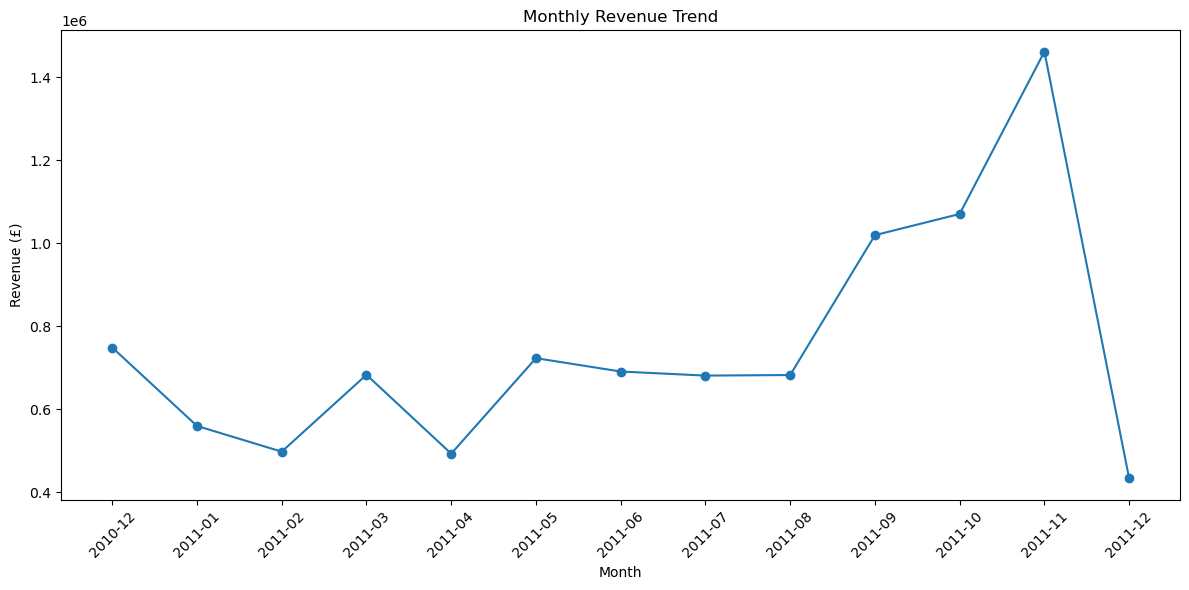

In [20]:
### Make sure InvoiceDate is in datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
# Calculate revenue for each transaction
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
# Extract year-month from InvoiceDate
df["Month"] = df["InvoiceDate"].dt.to_period("M")
# Aggregate transaction-level revenue by month
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .sort_values(ascending=False))
# Display monthly revenue
print("Monthly Revenue:")
display(monthly_revenue)
# Find the highest-revenue month
highest_revenue_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()
print(f"\nHighest Revenue Month: {highest_revenue_month}")
print(f"Revenue: £{highest_revenue:,.2f}")
# Visualize monthly revenue
monthly_revenue_plot = monthly_revenue.sort_index()
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_revenue_plot.index.astype(str),
    monthly_revenue_plot.values,
    marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# Q1. Insight
highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()
print("Business Insight:")
print(
    f"{highest_month} generated the highest monthly revenue "
    f"of £{highest_revenue:,.2f}."
)

Business Insight:
2011-11 generated the highest monthly revenue of £1,461,756.25.


Top 10 Countries by Revenue:


Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

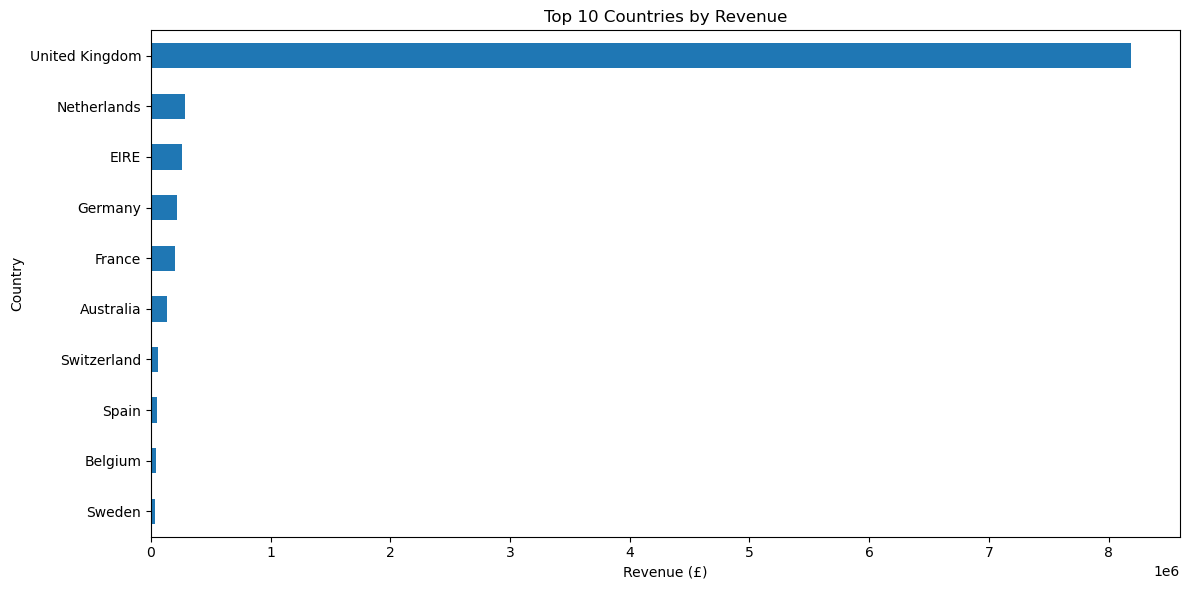

In [22]:
# Q2. Country-wise Revenue Analysis: Which countries generate the most revenue?
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False))
# Display top 10 countries
print("Top 10 Countries by Revenue:")
display(country_revenue.head(10))
# Visualize top 10 countries
plt.figure(figsize=(12, 6))
country_revenue.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [67]:
# 2 — Country Revenue Contribution
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False))
top_10_countries = country_revenue.head(10)
country_share = (top_10_countries / country_revenue.sum() * 100)
display(
    pd.DataFrame({
        "Revenue": top_10_countries,
        "Revenue Share (%)": country_share.round(2)}))

,Revenue,Revenue Share (%)
Country,,
United Kingdom,8187806.364,84.00
Netherlands,284661.540,2.92
EIRE,263276.820,2.70
Germany,221698.210,2.27
France,197403.900,2.03
Australia,137077.270,1.41
Switzerland,56385.350,0.58
Spain,54774.580,0.56
Belgium,40910.960,0.42


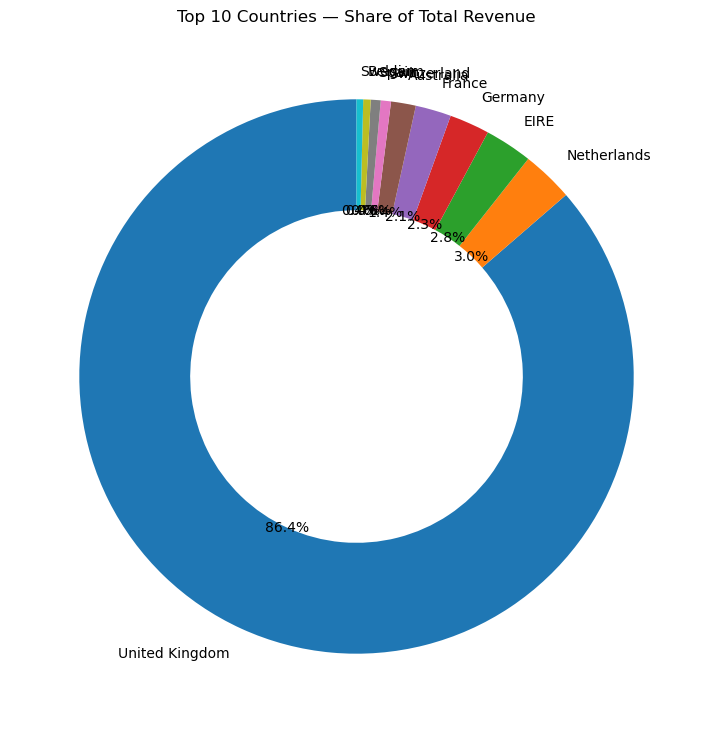

In [32]:
# Q2. Country Revenue Contribution : Which countries contribute the most to revenue?
# Version 2: Pie chart
country_revenue = (
    df.groupby("Country")["Revenue"].sum().sort_values(ascending=False))
# Keep top 10 countries
top_10 = country_revenue.head(10)
# Calculate percentage contribution
percentage = (top_10 / country_revenue.sum()) * 100
# Donut chart
plt.figure(figsize=(9, 9))
plt.pie(
    top_10,
    labels=top_10.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4})
plt.title("Top 10 Countries — Share of Total Revenue")
plt.show()

In [71]:
# 3 — Product Revenue Analysis
product_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False))
top_product = product_revenue.idxmax()
top_product_revenue = product_revenue.max()
print("Top Revenue-Generating Product:")
print(f"Product: {top_product}")
print(f"Revenue: £{top_product_revenue:,.2f}")

Top Revenue-Generating Product:
Product: DOTCOM POSTAGE
Revenue: £206,245.48


Top 10 Products by Revenue:


Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

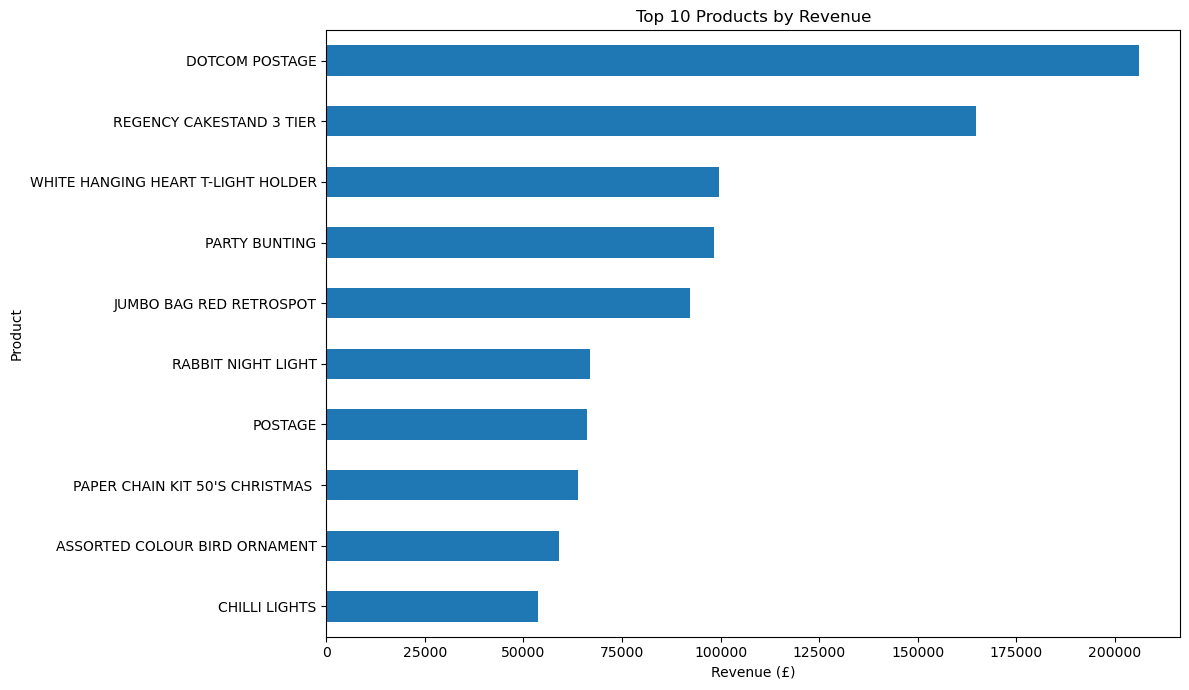

In [36]:
# Q3. Product Revenue Analysis: Which products generate the most revenue?
product_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False))
# Display top 10 products
print("Top 10 Products by Revenue:")
display(product_revenue.head(10))
# Visualize top 10 products
plt.figure(figsize=(12, 7))
product_revenue.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [73]:
# Q3. Key Insight
print(
    f"Key Insight: {top_product} generated the highest revenue, "
    f"with total revenue of £{top_product_revenue:,.2f}.")

Key Insight: DOTCOM POSTAGE generated the highest revenue, with total revenue of £206,245.48.


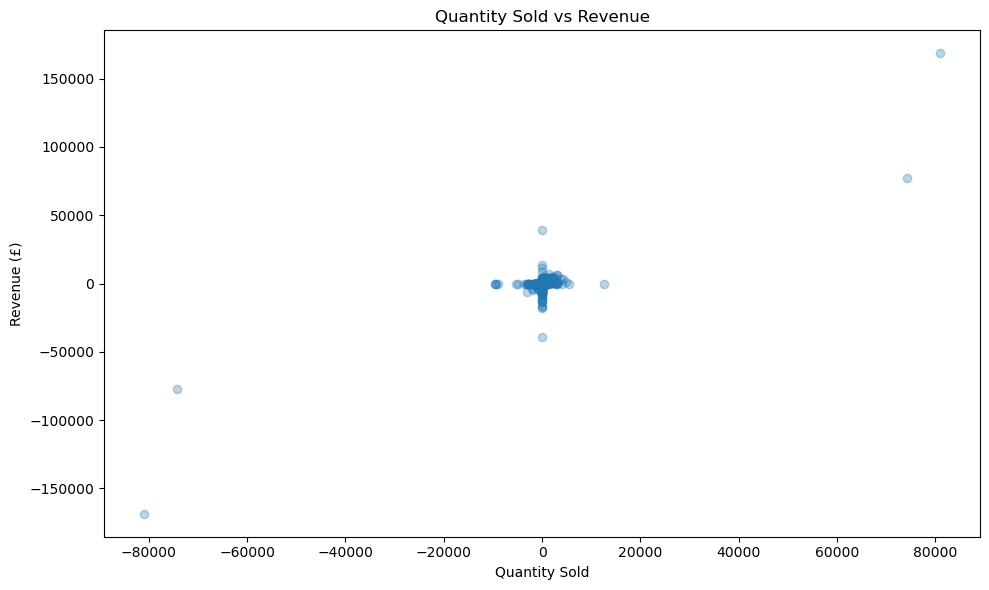

In [38]:
# Q4. Quantity vs Revenue Analysis: Is there a relationship between quantity sold and revenue?
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Quantity"],
    df["Revenue"],
    alpha=0.3)
plt.title("Quantity Sold vs Revenue")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [75]:
# Q4 — Quantity vs Revenue
# Calculate correlation
quantity_revenue_corr = df["Quantity"].corr(df["Revenue"])
print(f"Correlation between Quantity and Revenue: {quantity_revenue_corr:.2f}")
# Key Insight
if quantity_revenue_corr > 0.5:
    relationship = "a strong positive relationship"
elif quantity_revenue_corr > 0:
    relationship = "a positive relationship"
else:
    relationship = "a weak or negative relationship"
print(
    f"Key Insight: Quantity sold and revenue show {relationship}, "
    f"with a correlation coefficient of {quantity_revenue_corr:.2f}."
)

Correlation between Quantity and Revenue: 0.89
Key Insight: Quantity sold and revenue show a strong positive relationship, with a correlation coefficient of 0.89.


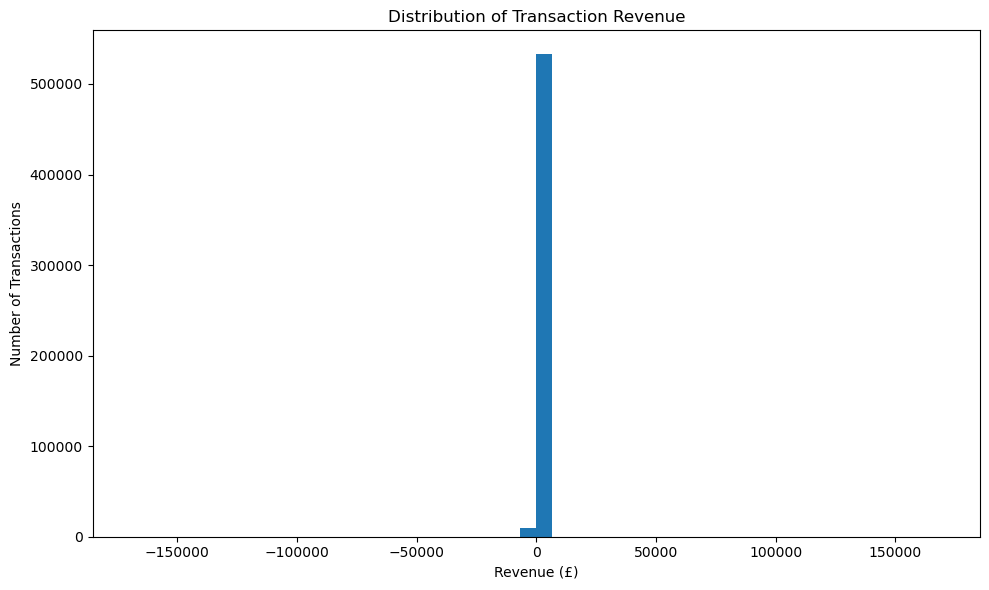

In [40]:
# Q5. Transaction Revenue Distribution: How is transaction revenue distributed?
plt.figure(figsize=(10, 6))
plt.hist(
    df["Revenue"],
    bins=50)
plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [89]:
# Q5 — Transaction Revenue Distribution
revenue_summary = df["Revenue"].describe()
display(revenue_summary)
mean_revenue = df["Revenue"].mean()
median_revenue = df["Revenue"].median()
max_revenue = df["Revenue"].max()
print(f"Mean Revenue per Transaction: £{mean_revenue:,.2f}")
print(f"Median Revenue per Transaction: £{median_revenue:,.2f}")
print(f"Maximum Revenue in a Transaction: £{max_revenue:,.2f}")
print("\nKey Insight:")
if mean_revenue > median_revenue:
    print(
        "The mean transaction revenue is higher than the median, "
        "indicating a right-skewed distribution with some "
        "higher-value transactions.")
else:
    print(
        "The mean transaction revenue is not higher than the median, "
        "suggesting a less right-skewed distribution.")

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

Mean Revenue per Transaction: £17.99
Median Revenue per Transaction: £9.75
Maximum Revenue in a Transaction: £168,469.60

Key Insight:
The mean transaction revenue is higher than the median, indicating a right-skewed distribution with some higher-value transactions.


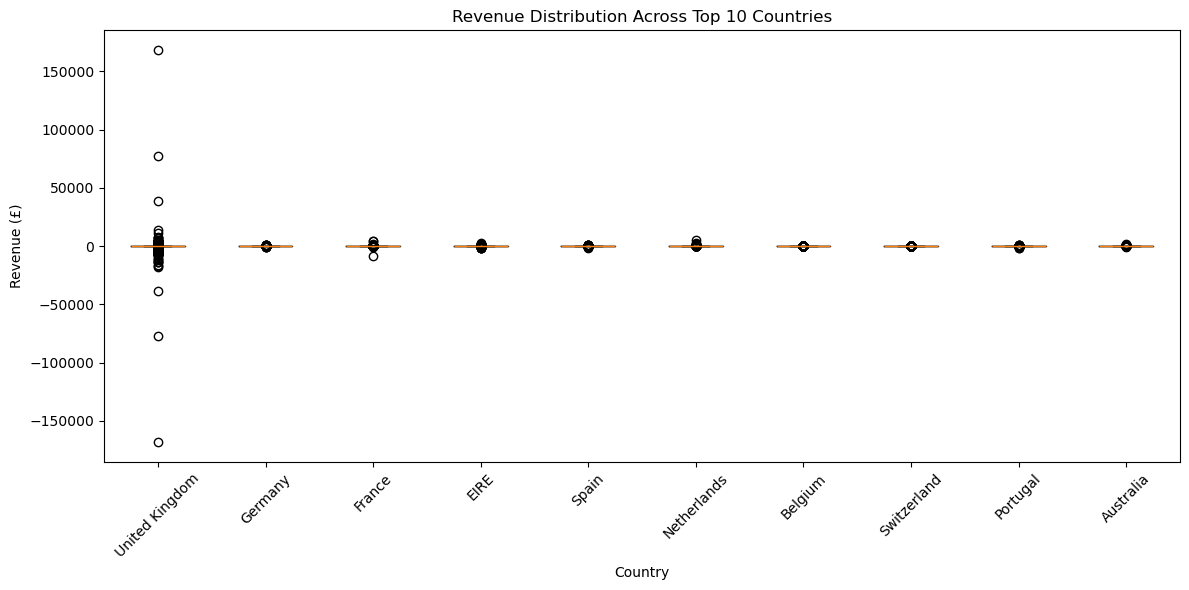

In [42]:
# Q6. Country-wise Revenue Distribution: How does transaction revenue vary across different countries?
# Select top 10 countries by transaction count
top_countries = df["Country"].value_counts().head(10).index
country_data = [
    df[df["Country"] == country]["Revenue"]
    for country in top_countries]
plt.figure(figsize=(12, 6))
plt.boxplot(
    country_data,
    labels=top_countries)
plt.title("Revenue Distribution Across Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
# Q6 — Country-wise Revenue Distribution
top_countries = df["Country"].value_counts().head(10).index
country_summary = (
    df[df["Country"].isin(top_countries)]
    .groupby("Country")["Revenue"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False))
display(country_summary)
# Country with highest average transaction revenue
highest_avg_country = country_summary["mean"].idxmax()
highest_avg_revenue = country_summary["mean"].max()
print(
    f"Key Insight: {highest_avg_country} has the highest average "
    f"transaction revenue among the top 10 countries, at "
    f"£{highest_avg_revenue:,.2f} per transaction.")

,count,mean,median,max
Country,,,,
Netherlands,2371,120.059696,91.80,4992.00
Australia,1259,108.877895,51.84,1718.40
EIRE,8196,32.122599,17.34,2365.20
Switzerland,2002,28.164510,17.40,360.00
Germany,9495,23.348943,16.60,876.00
France,8557,23.069288,16.50,4161.06
Spain,2533,21.624390,15.00,1350.00
Belgium,2069,19.773301,16.60,165.00
Portugal,1519,19.333127,15.80,1241.98


Key Insight: Netherlands has the highest average transaction revenue among the top 10 countries, at £120.06 per transaction.


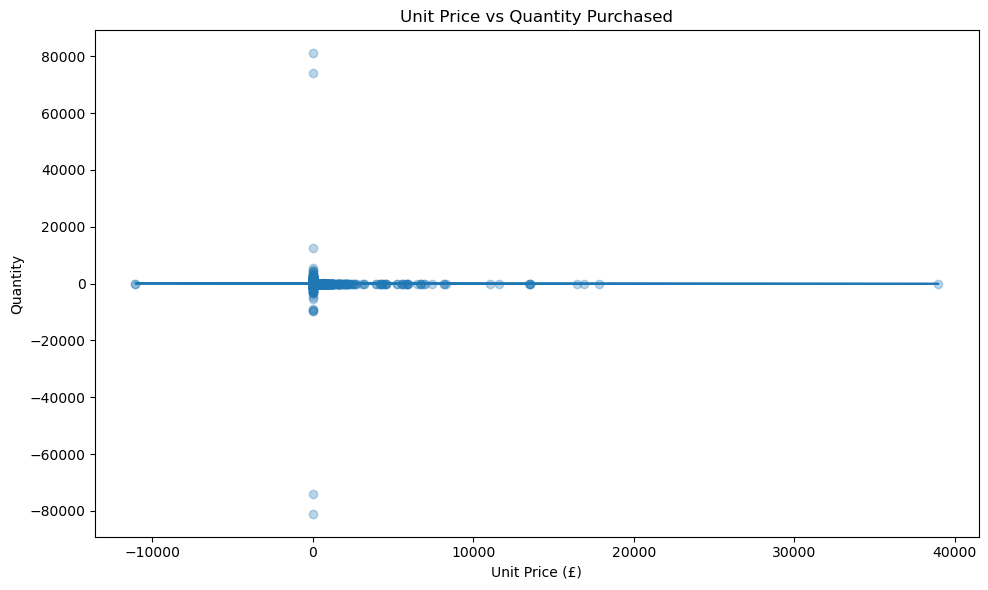

In [44]:
# Q7. Unit Price vs Quantity Analysis: Does unit price affect the quantity purchased?
plt.figure(figsize=(10, 6))
plt.scatter(
    df["UnitPrice"],
    df["Quantity"],
    alpha=0.3)
# Trendline
import numpy as np
x = df["UnitPrice"]
y = df["Quantity"]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x))
plt.title("Unit Price vs Quantity Purchased")
plt.xlabel("Unit Price (£)")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

In [91]:
# Q7 — Unit Price vs Quantity
price_quantity_corr = df["UnitPrice"].corr(df["Quantity"])
print(
    f"Correlation between Unit Price and Quantity: "
    f"{price_quantity_corr:.2f}")
# Key Insight
price_quantity_corr = df["UnitPrice"].corr(df["Quantity"])
print(f"Correlation: {price_quantity_corr:.2f}")
print(
    "Key Insight: Unit price and quantity purchased show "
    "almost no linear relationship in this dataset, "
    f"with a correlation coefficient of {price_quantity_corr:.2f}.")

Correlation between Unit Price and Quantity: -0.00
Correlation: -0.00
Key Insight: Unit price and quantity purchased show almost no linear relationship in this dataset, with a correlation coefficient of -0.00.


Monthly Transaction Volume:


Month
2010-12    2025
2011-01    1476
2011-02    1393
2011-03    1983
2011-04    1744
2011-05    2162
2011-06    2012
2011-07    1927
2011-08    1737
2011-09    2327
2011-10    2637
2011-11    3462
2011-12    1015
Freq: M, Name: InvoiceNo, dtype: int64

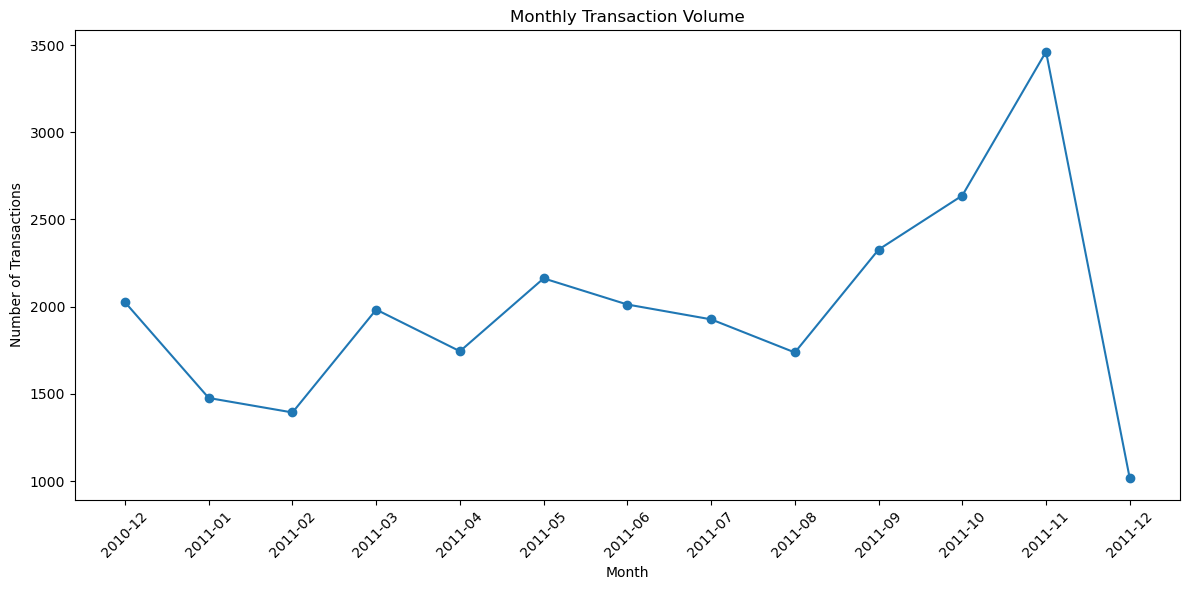

In [46]:
# Q8. Monthly Transaction Volume: How does the number of transactions change over time?
monthly_transactions = (
    df.groupby("Month")["InvoiceNo"]
      .nunique())
print("Monthly Transaction Volume:")
display(monthly_transactions)
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values,
    marker="o")
plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [83]:
# Q8 — Monthly Transaction Volume
monthly_transactions = (
    df.groupby("Month")["InvoiceNo"]
      .nunique())
highest_transaction_month = monthly_transactions.idxmax()
highest_transaction_count = monthly_transactions.max()
lowest_transaction_month = monthly_transactions.idxmin()
lowest_transaction_count = monthly_transactions.min()
print(f"Highest Transaction Month: {highest_transaction_month}")
print(f"Transactions: {highest_transaction_count:,}")
print(f"\nLowest Transaction Month: {lowest_transaction_month}")
print(f"Transactions: {lowest_transaction_count:,}")
print(
    f"\nKey Insight: {highest_transaction_month} recorded the highest "
    f"transaction volume with {highest_transaction_count:,} transactions, "
    f"while {lowest_transaction_month} recorded the lowest with "
    f"{lowest_transaction_count:,} transactions.")

Highest Transaction Month: 2011-11
Transactions: 3,462

Lowest Transaction Month: 2011-12
Transactions: 1,015

Key Insight: 2011-11 recorded the highest transaction volume with 3,462 transactions, while 2011-12 recorded the lowest with 1,015 transactions.


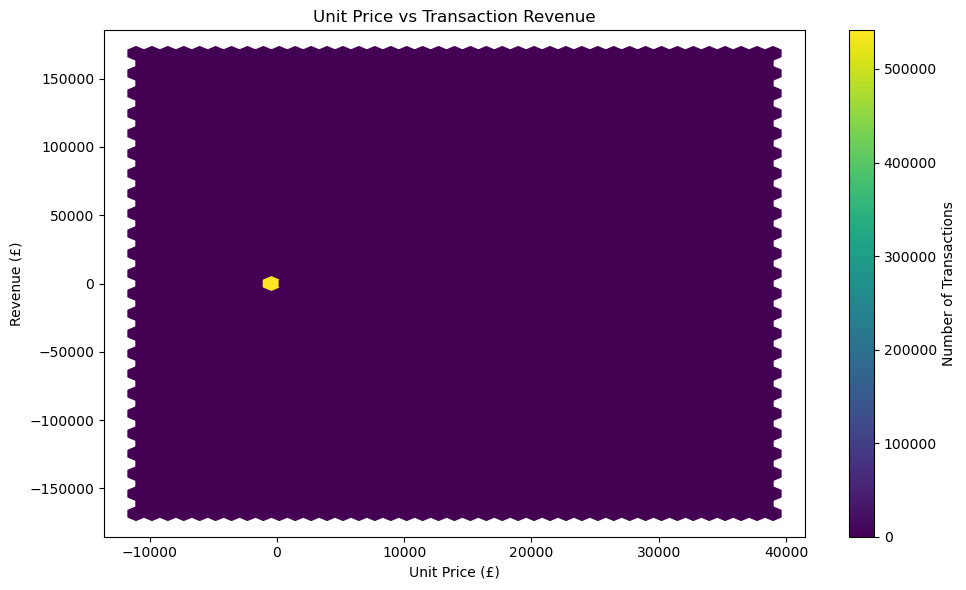

In [48]:
# Q9. Unit Price vs Revenue Analysis: How does unit price relate to transaction revenue?
plt.figure(figsize=(10, 6))
plt.hexbin(
    df["UnitPrice"],
    df["Revenue"],
    gridsize=40)
plt.colorbar(label="Number of Transactions")
plt.title("Unit Price vs Transaction Revenue")
plt.xlabel("Unit Price (£)")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [85]:
# Q9 — Unit Price vs Revenue
price_revenue_corr = df["UnitPrice"].corr(df["Revenue"])
print(
    f"Correlation between Unit Price and Revenue: "
    f"{price_revenue_corr:.2f}")
# Key Insight
if price_revenue_corr > 0.5:
    relationship = "a strong positive relationship"
elif price_revenue_corr > 0:
    relationship = "a positive relationship"
elif price_revenue_corr < -0.5:
    relationship = "a strong negative relationship"
else:
    relationship = "a weak or negative relationship"
print(
    f"Key Insight: Unit price and transaction revenue show "
    f"{relationship}, with a correlation coefficient of "
    f"{price_revenue_corr:.2f}.")

Correlation between Unit Price and Revenue: -0.16
Key Insight: Unit price and transaction revenue show a weak or negative relationship, with a correlation coefficient of -0.16.


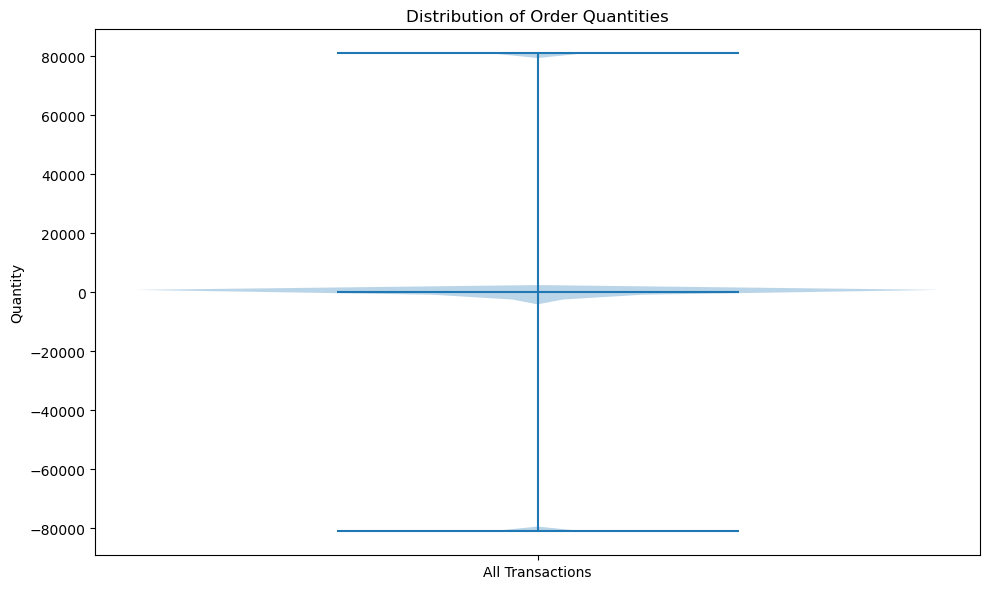

In [50]:
# Q10. Quantity Distribution Analysis: What is the distribution of order quantities?
plt.figure(figsize=(10, 6))
plt.violinplot(
    df["Quantity"],
    showmedians=True)
plt.title("Distribution of Order Quantities")
plt.ylabel("Quantity")
plt.xticks([1], ["All Transactions"])
plt.tight_layout()
plt.show()

In [93]:
# Q10 — Order Quantity Distribution
quantity_summary = df["Quantity"].describe()
display(quantity_summary)
mean_quantity = df["Quantity"].mean()
median_quantity = df["Quantity"].median()
max_quantity = df["Quantity"].max()
print(f"Mean Quantity per Transaction: {mean_quantity:.2f}")
print(f"Median Quantity per Transaction: {median_quantity:.2f}")
print(f"Maximum Quantity in a Transaction: {max_quantity:,.0f}")
print("\nKey Insight:")
if mean_quantity > median_quantity:
    print(
        "The mean quantity is higher than the median, indicating "
        "that the distribution is right-skewed due to some "
        "high-quantity transactions.")
else:
    print(
        "The mean quantity is not higher than the median, indicating "
        "that the distribution is not strongly right-skewed.")

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Mean Quantity per Transaction: 9.55
Median Quantity per Transaction: 3.00
Maximum Quantity in a Transaction: 80,995

Key Insight:
The mean quantity is higher than the median, indicating that the distribution is right-skewed due to some high-quantity transactions.


## Key Findings

- November 2011 recorded the highest monthly revenue at £1,461,756.25.
- The United Kingdom was the dominant revenue-generating country.
- DOTCOM POSTAGE generated the highest product-level revenue at £206,245.48.
- Quantity sold and revenue showed a strong positive relationship, with a correlation of approximately 0.89.
- The Netherlands recorded the highest average transaction revenue among the top 10 countries.
- November 2011 recorded the highest transaction volume, with 3,462 transactions.
- Unit price and quantity purchased showed almost no linear relationship, with a correlation close to 0.00.

### Business Recommendations

- **Prepare for seasonal demand:** November recorded the highest revenue and transaction volume, suggesting the business should plan inventory, staffig, and marketing resources ahead of high-demand period.

- **Focus on the UK market:** The United Kingdom contributed the largest share of revenue, so maintaining strong customer engagement and retention in this market should remain a priorty.

- **Optimize high-revenue products:** Products generating substantial revenue should be monitored closely to maintain availability and identify opportunities for cross-selling or targeted promoions.

- **Use quantity as a revenue driver:** The strong positive relationship between quantity sold and revenue suggests that strategies encouraging higher purchase volumes may support overall revenuegrowth.

- **Avoid assuming price alone drives quantity:** The near-zero relationship between unit price and quantity indicates that pricing changes alone may not strongly influence purchase quantity. Other customer and product factors should be investigated.

### Conclusion

Through this project, I explored the Online Retail dataset and tried to understand the business from a data perspective. I analyzed monthly revenue, transaction volume, country-wise performance, product revenue, quantity sod, and the relationship between price and quantity.

One of the main things I found was that November 2011 had the highest revenue and transaction volume. The analysis also showed a strong relationship between quantity sold and revenue, while unit price and quantity did not have much of a linear relationship.

Overall, this project helped me understand how EDA works in a real dataset — from cleaning the data and creating new columns to visualizing patterns and turning those patterns into meaningful business insights. It also gave me more practice with Pandas, Matplotlib, data visualization, and thinking about data beyond just writingcode.
